In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Drop ID column
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Convert categorical columns to numeric
df = pd.get_dummies(df)


X = df.drop("Churn_Yes", axis=1)

y =df["Churn_Yes"]
# remove leakage
if "Churn_No" in X.columns:
    X = X.drop("Churn_No", axis=1)

X_train_resampled, X_test, y_train_resampled, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [2]:
y_pred = model.predict(X_test)

In [3]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7725657427149965
              precision    recall  f1-score   support

       False       0.82      0.88      0.85      1028
        True       0.59      0.49      0.54       379

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [4]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.8101316181226451


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
import pandas as pd

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

top10 = (feature_importances.head(10))
print(top10)

TotalCharges                      0.160337
tenure                            0.141138
MonthlyCharges                    0.135911
Contract_Month-to-month           0.048546
PaymentMethod_Electronic check    0.033550
InternetService_Fiber optic       0.031153
OnlineSecurity_No                 0.029051
TechSupport_No                    0.025649
SeniorCitizen                     0.019869
gender_Female                     0.017532
dtype: float64


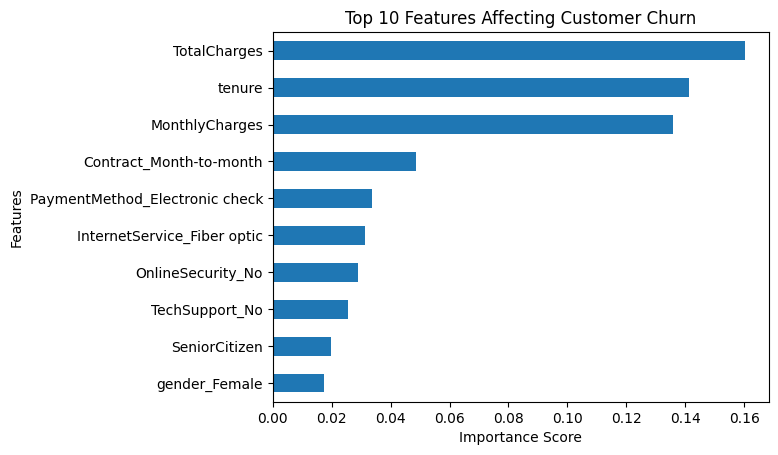

In [7]:
import matplotlib.pyplot as plt

top10.plot(kind="barh")

plt.title("Top 10 Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_resampled, y_train_resampled)

In [9]:
print(X.columns)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', '

In [10]:
print("Churn_No in features:", "Churn_No" in X.columns)

Churn_No in features: False


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    
    model.fit(X_train_resampled, y_train_resampled)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    print(f"{name}")
    print("Accuracy:", accuracy)
    print("ROC-AUC:", roc)
    print("-"*40)

c:\Users\pranav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.7818052594171997
ROC-AUC: 0.8363333264889171
----------------------------------------
Random Forest
Accuracy: 0.7725657427149965
ROC-AUC: 0.8097363530897406
----------------------------------------
Gradient Boosting
Accuracy: 0.7896233120113717
ROC-AUC: 0.8390873484389597
----------------------------------------


In [12]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb")) 


In [13]:
len(X.columns)

45

Contract_Month-to-month           0.372483
OnlineSecurity_No                 0.089525
PaymentMethod_Electronic check    0.077160
TechSupport_No                    0.065501
tenure                            0.058122
TotalCharges                      0.043231
InternetService_Fiber optic       0.035228
PaperlessBilling_Yes              0.027703
OnlineBackup_No                   0.026193
Contract_One year                 0.018332
dtype: float64


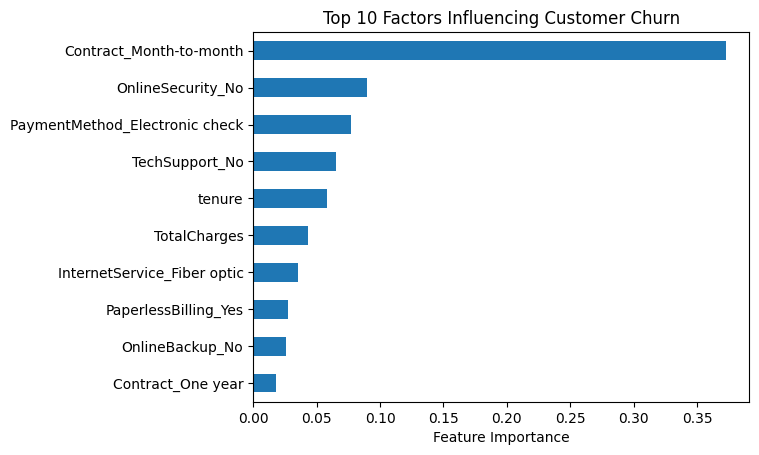

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

top10 = importance.head(10)

print(top10)

top10.plot(kind="barh")
plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [15]:
import pickle

with open("../model/churn_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../model/model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [16]:
pickle.dump(model, open("../model/churn_model.pkl","wb"))

In [17]:
pickle.dump(X.columns.tolist(), open("../model/model_columns.pkl","wb"))

In [18]:
import sys
import sklearn

print(sys.executable)
print(sklearn.__version__)

c:\Users\pranav\AppData\Local\Programs\Python\Python313\python.exe
1.7.2
